# Settings

In [1]:
options(scipen=999)
pacman::p_load(dplyr, stringr, data.table, tidyr, plyr,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,ggforce)


## Directories

In [2]:
# Set working directories
base.dir =  "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/"
assets.dir = paste(base.dir, "Assets/", sep = "") 
results.dir = paste(base.dir, "Results/corrected/", sep = "")
permutation.result.dir = paste(base.dir, "Results/corrected.permutation.test/", sep = "")


# Databases
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"

permutations.test.tmp.dir = paste(permutation.result.dir, "TMP/", sep = "")
permutations.test.res.dir = paste(permutation.result.dir, "Results/", sep = "")

cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

## Variables

In [3]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

# Contrasts
Contrast_1 = c(condition.ls[2], condition.ls[3], condition.ls[4])
Contrast_2 = c(condition.ls[1], condition.ls[1], condition.ls[1])

# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

Cellpop.compartment = as.data.frame(cbind(cell.pop.order, compartment))
Cellpop.compartment$compartment = factor(Cellpop.compartment$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
colnames(Cellpop.compartment)[1] = "Celltype"

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

Cellpop.compartment$colors.compartments = compartment
Cellpop.compartment$colors.compartments = mapvalues(Cellpop.compartment$colors.compartments, names(colors.compartments), colors.compartments, warn_missing = TRUE)
gaps.compartments = c(3, 9, 11, 12)

# Permutation test

## Observations

In [4]:
LR.data.consensus.sig.thresh = read.table(paste(results.dir,
                                               "LR.data.consensus.sig.thresh.txt", sep = ""),
                                          sep = "\t", stringsAsFactors = F, header = T)
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$target %in% cell.pop.order, ]
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$source %in% cell.pop.order, ]

In [5]:
# Split LR pairs
LR.data.ND = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[1], ]
LR.data.AAB = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[2], ]
LR.data.ETD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[3], ]
LR.data.LTD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[4], ]
nrow(LR.data.consensus.sig.thresh)
# Print stats
message("LR pairs in ND: ", nrow(LR.data.ND))
message("LR pairs in AAB : ", nrow(LR.data.AAB))
message("LR pairs in Early T1D: ", nrow(LR.data.ETD))
message("LR pairs in Late T1D: ", nrow(LR.data.LTD))

[1] 87650

LR pairs in ND: 27139

LR pairs in AAB : 27459

LR pairs in Early T1D: 18179

LR pairs in Late T1D: 14873



In [6]:
head(LR.data.consensus.sig.thresh, n=1)

,ligand,source,target,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,⋯,FDR,interaction.id,compartment.source,compartment.target,Type,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,ADCYAP1R1,0.00006164112,0.0001,ADCYAP1_ADCYAP1R1,ADCYAP1 - ADCYAP1R1,PACAP,Secreted Signaling,⋯,0.000153715,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,Endocrine,Stromal,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family


In [7]:
condition.sizes = c(nrow(LR.data.ND), nrow(LR.data.AAB), nrow(LR.data.ETD), nrow(LR.data.LTD))
condition.sizes

condition.size_1 = c(condition.sizes[2], condition.sizes[3], condition.sizes[4])
condition.size_2 = c(condition.sizes[1], condition.sizes[1], condition.sizes[1])

[1] 27139 27459 18179 14873

In [8]:
nsim = 100

# Signaling roles - Outgoing

In [9]:
LR.data.consensus.use = LR.data.consensus.sig.thresh

## Observed value

In [10]:
# Load source and target cells
sources = cell.pop.order
targets = cell.pop.order
diff.obs.ls = vector(mode = "list", length = length(Contrast_1))
abs.diff.obs.ls = vector(mode = "list", length = length(Contrast_1))
for (i in seq_along(Contrast_1)){
        diff.obs.data = NULL
        abs.diff.obs.data = NULL
        for (cell.i in seq_along(sources)){
        # Subset to target cell
        target.cell = sources[cell.i]
        LR.data.use <- LR.data.consensus.use[LR.data.consensus.use$source== target.cell,]
        message("Detected: ", nrow(LR.data.use), " significant interactions from ",  target.cell)
        # Subset for the contrast
        contrast = c(Contrast_1[i], Contrast_2[i])
        message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
        LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
        LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
        message("Distribution of interactions in contrast: \n",
                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                Contrast_2[i], ": ", nrow(LR.data.c2))
        message("normalization: \n",
                Contrast_1[i], ": ", condition.size_1[i], "\n",
                Contrast_2[i], ": ", condition.size_2[i])
        # Sum all interctions AND NORMALIZE by condition size
        LR.data.c1.unique <- sum(LR.data.c1[, 'prob'])/condition.size_1[i]
        LR.data.c2.unique <- sum(LR.data.c2[, 'prob'])/condition.size_2[i]
    
        # Compute difference
        diff.obs = LR.data.c1.unique - LR.data.c2.unique
        names(diff.obs) = contrast[1]
        abs.diff.obs = abs(diff.obs)
        # pile up results
        diff.obs.data = cbind(diff.obs.data, diff.obs)
        colnames(diff.obs.data)[ncol(diff.obs.data)] = target.cell
        abs.diff.obs.data = cbind(abs.diff.obs.data, abs.diff.obs)
        colnames(abs.diff.obs.data)[ncol(abs.diff.obs.data)] = target.cell
    }
    diff.obs.ls[[i]] = diff.obs.data
    abs.diff.obs.ls[[i]] = abs.diff.obs.data
}

Detected: 6093 significant interactions from Alpha

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1826
ND: 1766

normalization: 
Aab: 27459
ND: 27139

Detected: 5224 significant interactions from Beta

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1632
ND: 1583

normalization: 
Aab: 27459
ND: 27139

Detected: 5211 significant interactions from Delta

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1919
ND: 2092

normalization: 
Aab: 27459
ND: 27139

Detected: 1920 significant interactions from Acinar1_2_6

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 559
ND: 537

normalization: 
Aab: 27459
ND: 27139

Detected: 1697 significant interactions from Acinar_3

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 515
ND: 494

normalization: 
Aab: 27459
ND: 27139

Detected: 1974 significant interactions from Acinar_4

Processing Aab vs ND

Distribution of interactions in contrast: 
A

## Compare with simulation

In [11]:
setwd(permutations.test.tmp.dir)

In [12]:
diff.sim.ls = vector(mode = "list", length = length(Contrast_1))
abs.diff.sim.ls = vector(mode = "list", length = length(Contrast_1))

for (i in seq_along(Contrast_1)){
    # Get files
    sim.list <- dir(pattern = "_DFnet.txt")
    diff.sim.data.tmp = NULL
    abs.diff.sim.data.tmp = NULL
    for (s.i in seq_along(sim.list)){
        print(paste("Processing: ", sim.list[s.i]))
        diff.sim.data = NULL
        abs.diff.sim.data = NULL
        # Load simulation data
        LR.data <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T)
        LR.data = na.omit(LR.data)
        message("\t Detected: ", nrow(LR.data), " interactions")
        for (cell.i in seq_along(sources)){
            # Subset for the contrast
            contrast = c(Contrast_1[i], Contrast_2[i])
            message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
            LR.data.c1 = LR.data[LR.data$condition %in% contrast[1], ]
            LR.data.c2 = LR.data[LR.data$condition %in% contrast[2], ]
            # Grab condition size
            sim.condition.sizes = c(nrow(LR.data.c1), nrow(LR.data.c2))            
            # Subset to target cell
            target.cell = sources[cell.i]
            LR.data.c1 = LR.data.c1[LR.data.c1$source == target.cell,]
            LR.data.c2 = LR.data.c2[LR.data.c2$source == target.cell,]
            message("Processing: ",  target.cell)
        message("Distribution of interactions in contrast: \n",
                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                Contrast_2[i], ": ", nrow(LR.data.c2))
        message("normalization: \n",
                Contrast_1[i], ": ", sim.condition.sizes[1], "\n",
                Contrast_2[i], ": ", sim.condition.sizes[2])
            # Sum all interctions AND NORMALIZE by condition size
            LR.data.c1.unique <- sum(LR.data.c1[, 'prob'])/sim.condition.sizes[1]
            LR.data.c2.unique <- sum(LR.data.c2[, 'prob'])/sim.condition.sizes[2]         
            # Compute difference
            diff.sim = LR.data.c1.unique - LR.data.c2.unique
            names(diff.sim) = s.i
            abs.diff.sim = abs(diff.sim)
            # pile up results
            diff.sim.data = cbind(diff.sim.data, diff.sim)
            colnames(diff.sim.data)[ncol(diff.sim.data)] = target.cell
            abs.diff.sim.data = cbind(abs.diff.sim.data, abs.diff.sim)
            colnames(abs.diff.sim.data)[ncol(abs.diff.sim.data)] = target.cell
            }
        diff.sim.data.tmp = rbind(diff.sim.data.tmp, diff.sim.data)
        abs.diff.sim.data.tmp = rbind(abs.diff.sim.data.tmp, abs.diff.sim.data)
    }
    diff.sim.ls[[i]] = diff.sim.data.tmp
    abs.diff.sim.ls[[i]] = abs.diff.sim.data.tmp
}   

[1] "Processing:  CellChat_Permutation_n1_DFnet.txt"


	 Detected: 99555 interactions

Processing Aab vs ND

Processing: Alpha

Distribution of interactions in contrast: 
Aab: 1752
ND: 1558

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Beta

Distribution of interactions in contrast: 
Aab: 1585
ND: 1401

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Delta

Distribution of interactions in contrast: 
Aab: 2101
ND: 1484

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
Aab: 566
ND: 451

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
Aab: 479
ND: 462

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
Aab: 594
ND: 467

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar_5

Distribution of interactions in contrast: 
Aab: 495
ND: 488

normal

[1] "Processing:  CellChat_Permutation_n10_DFnet.txt"


	 Detected: 100481 interactions

Processing Aab vs ND

Processing: Alpha

Distribution of interactions in contrast: 
Aab: 1632
ND: 1783

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Beta

Distribution of interactions in contrast: 
Aab: 1505
ND: 1660

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Delta

Distribution of interactions in contrast: 
Aab: 2050
ND: 2038

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
Aab: 525
ND: 544

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
Aab: 463
ND: 485

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
Aab: 572
ND: 585

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar_5

Distribution of interactions in contrast: 
Aab: 468
ND: 507

norma

[1] "Processing:  CellChat_Permutation_n100_DFnet.txt"


...

	 Detected: 100999 interactions

Processing T1D_late vs ND

Processing: Alpha

Distribution of interactions in contrast: 
T1D_late: 1584
ND: 1658

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Beta

Distribution of interactions in contrast: 
T1D_late: 1361
ND: 1483

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Delta

Distribution of interactions in contrast: 
T1D_late: 1435
ND: 2004

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
T1D_late: 523
ND: 528

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
T1D_late: 421
ND: 454

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
T1D_late: 502
ND: 564

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late 

[1] "Processing:  CellChat_Permutation_n98_DFnet.txt"


	 Detected: 99113 interactions

Processing T1D_late vs ND

Processing: Alpha

Distribution of interactions in contrast: 
T1D_late: 1710
ND: 1716

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Beta

Distribution of interactions in contrast: 
T1D_late: 1518
ND: 1612

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Delta

Distribution of interactions in contrast: 
T1D_late: 1620
ND: 2011

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
T1D_late: 511
ND: 577

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
T1D_late: 473
ND: 497

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
T1D_late: 562
ND: 621

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late v

[1] "Processing:  CellChat_Permutation_n99_DFnet.txt"


	 Detected: 100786 interactions

Processing T1D_late vs ND

Processing: Alpha

Distribution of interactions in contrast: 
T1D_late: 1655
ND: 1837

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Beta

Distribution of interactions in contrast: 
T1D_late: 1440
ND: 1636

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Delta

Distribution of interactions in contrast: 
T1D_late: 1480
ND: 2167

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
T1D_late: 516
ND: 586

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
T1D_late: 445
ND: 512

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
T1D_late: 537
ND: 652

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late 

In [13]:
stars = data.frame(ND = rep("", times = length(cell.pop.order)))
pvalue.write = NULL

for (i in seq_along(Contrast_1)){
    print(paste("Processing ", Contrast_1[i], " vs ", Contrast_2[i]))
    random.success.table = NULL
        for (x in 1:ncol(abs.diff.sim.ls[[i]])){
            message("Testing ", colnames(abs.diff.sim.ls[[i]])[x], " against ",
                   colnames(abs.diff.obs.ls[[i]])[x])
            test = abs.diff.sim.ls[[i]][,x] > abs.diff.obs.ls[[i]][x]
            random.success.table = cbind(random.success.table, test)
            colnames(random.success.table)[ncol(random.success.table)] = colnames(abs.diff.sim.ls[[i]])[x]
        }
    random.success = colSums(random.success.table == "TRUE", na.rm = TRUE)
    pvalue = random.success/nsim
    ## Modify pvalue of results that had observed difference = 0 
    #~ When there is no interaction found in the observation, the difference between conditions will be exactly 0
    #~ By design we are filtering the simulations for interactions found in the observations, so none 
    #~ of the simulations will never have interactions and thus the permutation test will always succed
    pvalue = replace(pvalue, diff.obs.ls[[i]] == 0, 1)
    # Make dataframe for stars
    stars.tpm = pvalue
    stars.tpm[pvalue>0.05]<-""
    stars.tpm[pvalue<=0.05]<-"*"
    stars.tpm[pvalue<=0.01]<-"**"
    stars.tpm[pvalue==0]<-"***"
    stars.tpm = data.frame(stars = stars.tpm)
    colnames(stars.tpm)[ncol(stars.tpm)] = Contrast_1[i]
    stars = cbind(stars, stars.tpm)
    pvalue.write = cbind(pvalue.write, pvalue)
}

[1] "Processing  Aab  vs  ND"


Testing Alpha against Alpha

Testing Beta against Beta

Testing Delta against Delta

Testing Acinar1_2_6 against Acinar1_2_6

Testing Acinar_3 against Acinar_3

Testing Acinar_4 against Acinar_4

Testing Acinar_5 against Acinar_5

Testing Ductal against Ductal

Testing MUC5b_Ductal against MUC5b_Ductal

Testing Tcells against Tcells

Testing Macrophage against Macrophage

Testing Endothelial against Endothelial

Testing Activated_Stellate against Activated_Stellate

Testing Quiescent_Stellate against Quiescent_Stellate



[1] "Processing  T1D_early  vs  ND"


Testing Alpha against Alpha

Testing Beta against Beta

Testing Delta against Delta

Testing Acinar1_2_6 against Acinar1_2_6

Testing Acinar_3 against Acinar_3

Testing Acinar_4 against Acinar_4

Testing Acinar_5 against Acinar_5

Testing Ductal against Ductal

Testing MUC5b_Ductal against MUC5b_Ductal

Testing Tcells against Tcells

Testing Macrophage against Macrophage

Testing Endothelial against Endothelial

Testing Activated_Stellate against Activated_Stellate

Testing Quiescent_Stellate against Quiescent_Stellate



[1] "Processing  T1D_late  vs  ND"


Testing Alpha against Alpha

Testing Beta against Beta

Testing Delta against Delta

Testing Acinar1_2_6 against Acinar1_2_6

Testing Acinar_3 against Acinar_3

Testing Acinar_4 against Acinar_4

Testing Acinar_5 against Acinar_5

Testing Ductal against Ductal

Testing MUC5b_Ductal against MUC5b_Ductal

Testing Tcells against Tcells

Testing Macrophage against Macrophage

Testing Endothelial against Endothelial

Testing Activated_Stellate against Activated_Stellate

Testing Quiescent_Stellate against Quiescent_Stellate



In [14]:
# Change colnames with condition names
colnames(pvalue.write) = Contrast_1
pvalue.write[pvalue.write == 0] <- 0.0001
# Apply FDR correction
pvalue.write = apply(pvalue.write, 2, function(x) p.adjust(x, method = "BH"))
                     
# counting stars, again
stars = pvalue.write
stars[pvalue.write > 0.1] <- ""
stars[pvalue.write < 0.1] <- "*"
stars[pvalue.write < 0.05] <- "**"
stars[pvalue.write < 0.001] <- "***"

In [15]:
pvalue.write

,Aab,T1D_early,T1D_late
Alpha,1,0.04666667,0.35636364
Beta,1,0.00140000,0.02800000
Delta,1,0.04666667,0.00070000
Acinar1_2_6,1,0.57166667,0.89000000
Acinar_3,1,0.78000000,0.89000000
Acinar_4,1,0.16800000,0.22400000
Acinar_5,1,0.74307692,0.22400000
Ductal,1,0.33600000,0.02800000
MUC5b_Ductal,1,0.07000000,0.17500000
Tcells,1,0.31500000,0.04666667


In [16]:
setwd(permutations.test.res.dir)
file.name = paste("Permutation.test_Signaling.roles.outgoing.res", sep = "")
write.table(stars, file.name, sep = "\t", quote = F, col.names=T, row.names = T)
file.name = paste("Permutation.test_Signaling.roles.outgoing.FDR.res", sep = "")
write.table(pvalue.write, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

# Signaling roles - Incoming

## Observed value

In [17]:
# Load source and target cells
sources = cell.pop.order
targets = cell.pop.order
diff.obs.ls = vector(mode = "list", length = length(Contrast_1))
abs.diff.obs.ls = vector(mode = "list", length = length(Contrast_1))
for (i in seq_along(Contrast_1)){
        diff.obs.data = NULL
        abs.diff.obs.data = NULL
        for (cell.i in seq_along(targets)){
        # Subset to target cell
        target.cell = targets[cell.i]
        LR.data.use <- LR.data.consensus.use[LR.data.consensus.use$target== target.cell,]
        message("Detected: ", nrow(LR.data.use), " significant interactions from ",  target.cell)
        # Subset for the contrast
        contrast = c(Contrast_1[i], Contrast_2[i])
        message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
        LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
        LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
        message("Distribution of interactions in contrast: \n",
                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                Contrast_2[i], ": ", nrow(LR.data.c2))
        message("normalization: \n",
                Contrast_1[i], ": ", condition.size_1[i], "\n",
                Contrast_2[i], ": ", condition.size_2[i])
        # Sum all interctions AND NORMALIZE by condition size
        LR.data.c1.unique <- sum(LR.data.c1[, 'prob'])/condition.size_1[i]
        LR.data.c2.unique <- sum(LR.data.c2[, 'prob'])/condition.size_2[i]
        # Compute difference
        diff.obs = LR.data.c1.unique - LR.data.c2.unique
        names(diff.obs) = contrast[1]
        abs.diff.obs = abs(diff.obs)
        # pile up results
        diff.obs.data = cbind(diff.obs.data, diff.obs)
        colnames(diff.obs.data)[ncol(diff.obs.data)] = target.cell
        abs.diff.obs.data = cbind(abs.diff.obs.data, abs.diff.obs)
        colnames(abs.diff.obs.data)[ncol(abs.diff.obs.data)] = target.cell
    }
    diff.obs.ls[[i]] = diff.obs.data
    abs.diff.obs.ls[[i]] = abs.diff.obs.data
}

Detected: 6078 significant interactions from Alpha

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1868
ND: 1810

normalization: 
Aab: 27459
ND: 27139

Detected: 5700 significant interactions from Beta

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1597
ND: 1700

normalization: 
Aab: 27459
ND: 27139

Detected: 4766 significant interactions from Delta

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1746
ND: 1863

normalization: 
Aab: 27459
ND: 27139

Detected: 5571 significant interactions from Acinar1_2_6

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1594
ND: 1647

normalization: 
Aab: 27459
ND: 27139

Detected: 6266 significant interactions from Acinar_3

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 1853
ND: 1817

normalization: 
Aab: 27459
ND: 27139

Detected: 5719 significant interactions from Acinar_4

Processing Aab vs ND

Distribution of interactions in contrast

## Compare with simulation

In [18]:
setwd(permutations.test.tmp.dir)
diff.sim.ls = vector(mode = "list", length = length(Contrast_1))
abs.diff.sim.ls = vector(mode = "list", length = length(Contrast_1))

for (i in seq_along(Contrast_1)){
    # Get files
    sim.list <- dir(pattern = "_DFnet.txt")
    diff.sim.data.tmp = NULL
    abs.diff.sim.data.tmp = NULL
    for (s.i in seq_along(sim.list)){
        print(paste("Processing: ", sim.list[s.i]))
        diff.sim.data = NULL
        abs.diff.sim.data = NULL
        # Load simulation data
        LR.data <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T) 
        LR.data = na.omit(LR.data)           
        message("\t Detected: ", nrow(LR.data), " interactions")
        for (cell.i in seq_along(targets)){
            # Subset for the contrast
            contrast = c(Contrast_1[i], Contrast_2[i])
            message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
            LR.data.c1 = LR.data[LR.data$condition %in% contrast[1], ]
            LR.data.c2 = LR.data[LR.data$condition %in% contrast[2], ]
            # Grab condition size
            sim.condition.sizes = c(nrow(LR.data.c1), nrow(LR.data.c2))                    
            # Subset to target cell
            target.cell = targets[cell.i]
            LR.data.c1 = LR.data.c1[LR.data.c1$target == target.cell,]
            LR.data.c2 = LR.data.c2[LR.data.c2$target == target.cell,]            
            message("Processing: ",  target.cell)
            message("Distribution of interactions in contrast: \n",
                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                Contrast_2[i], ": ", nrow(LR.data.c2))
            message("normalization: \n",
                Contrast_1[i], ": ", sim.condition.sizes[1], "\n",
                Contrast_2[i], ": ", sim.condition.sizes[2])
            # Sum all interctions AND NORMALIZE by condition size
            LR.data.c1.unique <- sum(LR.data.c1[, 'prob'])/sim.condition.sizes[1]
            LR.data.c2.unique <- sum(LR.data.c2[, 'prob'])/sim.condition.sizes[2]            
            # Compute difference
            diff.sim = LR.data.c1.unique - LR.data.c2.unique
            names(diff.sim) = s.i
            abs.diff.sim = abs(diff.sim)
            # pile up results
            diff.sim.data = cbind(diff.sim.data, diff.sim)
            colnames(diff.sim.data)[ncol(diff.sim.data)] = target.cell
            abs.diff.sim.data = cbind(abs.diff.sim.data, abs.diff.sim)
            colnames(abs.diff.sim.data)[ncol(abs.diff.sim.data)] = target.cell
            }
        diff.sim.data.tmp = rbind(diff.sim.data.tmp, diff.sim.data)
        abs.diff.sim.data.tmp = rbind(abs.diff.sim.data.tmp, abs.diff.sim.data)
    }
    diff.sim.ls[[i]] = diff.sim.data.tmp
    abs.diff.sim.ls[[i]] = abs.diff.sim.data.tmp
}

[1] "Processing:  CellChat_Permutation_n1_DFnet.txt"


	 Detected: 99555 interactions

Processing Aab vs ND

Processing: Alpha

Distribution of interactions in contrast: 
Aab: 1806
ND: 1555

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Beta

Distribution of interactions in contrast: 
Aab: 1632
ND: 1563

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Delta

Distribution of interactions in contrast: 
Aab: 1933
ND: 1393

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
Aab: 1642
ND: 1368

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
Aab: 1822
ND: 1542

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
Aab: 1728
ND: 1439

normalization: 
Aab: 27464
ND: 22024

Processing Aab vs ND

Processing: Acinar_5

Distribution of interactions in contrast: 
Aab: 1614
ND: 1413

[1] "Processing:  CellChat_Permutation_n10_DFnet.txt"


	 Detected: 100481 interactions

Processing Aab vs ND

Processing: Alpha

Distribution of interactions in contrast: 
Aab: 1661
ND: 1885

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Beta

Distribution of interactions in contrast: 
Aab: 1638
ND: 1775

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Delta

Distribution of interactions in contrast: 
Aab: 1797
ND: 1875

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
Aab: 1573
ND: 1579

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
Aab: 1792
ND: 1762

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
Aab: 1681
ND: 1655

normalization: 
Aab: 25931
ND: 27308

Processing Aab vs ND

Processing: Acinar_5

Distribution of interactions in contrast: 
Aab: 1563
ND: 157

[1] "Processing:  CellChat_Permutation_n100_DFnet.txt"


...

	 Detected: 100999 interactions

Processing T1D_late vs ND

Processing: Alpha

Distribution of interactions in contrast: 
T1D_late: 1423
ND: 1713

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Beta

Distribution of interactions in contrast: 
T1D_late: 1205
ND: 1602

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Delta

Distribution of interactions in contrast: 
T1D_late: 1269
ND: 1655

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
T1D_late: 1414
ND: 1586

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
T1D_late: 1569
ND: 1744

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D_late vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
T1D_late: 1432
ND: 1640

normalization: 
T1D_late: 22878
ND: 25650

Processing T1D

[1] "Processing:  CellChat_Permutation_n98_DFnet.txt"


	 Detected: 99113 interactions

Processing T1D_late vs ND

Processing: Alpha

Distribution of interactions in contrast: 
T1D_late: 1581
ND: 1725

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Beta

Distribution of interactions in contrast: 
T1D_late: 1478
ND: 1689

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Delta

Distribution of interactions in contrast: 
T1D_late: 1530
ND: 1796

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
T1D_late: 1539
ND: 1581

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
T1D_late: 1806
ND: 1764

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_late vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
T1D_late: 1584
ND: 1679

normalization: 
T1D_late: 24739
ND: 27409

Processing T1D_

[1] "Processing:  CellChat_Permutation_n99_DFnet.txt"


	 Detected: 100786 interactions

Processing T1D_late vs ND

Processing: Alpha

Distribution of interactions in contrast: 
T1D_late: 1479
ND: 1901

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Beta

Distribution of interactions in contrast: 
T1D_late: 1334
ND: 1805

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Delta

Distribution of interactions in contrast: 
T1D_late: 1315
ND: 1981

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Acinar1_2_6

Distribution of interactions in contrast: 
T1D_late: 1472
ND: 1670

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Acinar_3

Distribution of interactions in contrast: 
T1D_late: 1536
ND: 1886

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D_late vs ND

Processing: Acinar_4

Distribution of interactions in contrast: 
T1D_late: 1509
ND: 1815

normalization: 
T1D_late: 23667
ND: 28311

Processing T1D

In [19]:
stars = data.frame(ND = rep("", times = length(cell.pop.order)))
pvalue.write = NULL
for (i in seq_along(Contrast_1)){
    print(paste("Processing ", Contrast_1[i], " vs ", Contrast_2[i]))
    random.success.table = NULL
        for (x in 1:ncol(abs.diff.sim.ls[[i]])){
            message("Testing ", colnames(abs.diff.sim.ls[[i]])[x], " against ",
                   colnames(abs.diff.obs.ls[[i]])[x])
            test = abs.diff.sim.ls[[i]][,x] > abs.diff.obs.ls[[i]][x]
            random.success.table = cbind(random.success.table, test)
            colnames(random.success.table)[ncol(random.success.table)] = colnames(abs.diff.sim.ls[[i]])[x]
        }
    random.success = colSums(random.success.table == "TRUE", na.rm = TRUE)
    pvalue = random.success/nsim
    ## Modify pvalue of results that had observed difference = 0 
    #~ When there is no interaction found in the observation, the difference between conditions will be exactly 0
    #~ By design we are filtering the simulations for interactions found in the observations, so none 
    #~ of the simulations will never have interactions and thus the permutation test will always succed
    # pvalue = replace(pvalue, diff.obs.ls[[i]] == 0, 1)
    # Make dataframe for stars
    stars.tpm = pvalue
    stars.tpm[pvalue>0.05]<-""
    stars.tpm[pvalue<=0.05]<-"*"
    stars.tpm[pvalue<=0.01]<-"**"
    stars.tpm[pvalue==0]<-"***"
    stars.tpm = data.frame(stars = stars.tpm)
    colnames(stars.tpm)[ncol(stars.tpm)] = Contrast_1[i]
    stars = cbind(stars, stars.tpm)
    pvalue.write = cbind(pvalue.write, pvalue)
}

[1] "Processing  Aab  vs  ND"


Testing Alpha against Alpha

Testing Beta against Beta

Testing Delta against Delta

Testing Acinar1_2_6 against Acinar1_2_6

Testing Acinar_3 against Acinar_3

Testing Acinar_4 against Acinar_4

Testing Acinar_5 against Acinar_5

Testing Ductal against Ductal

Testing MUC5b_Ductal against MUC5b_Ductal

Testing Tcells against Tcells

Testing Macrophage against Macrophage

Testing Endothelial against Endothelial

Testing Activated_Stellate against Activated_Stellate

Testing Quiescent_Stellate against Quiescent_Stellate



[1] "Processing  T1D_early  vs  ND"


Testing Alpha against Alpha

Testing Beta against Beta

Testing Delta against Delta

Testing Acinar1_2_6 against Acinar1_2_6

Testing Acinar_3 against Acinar_3

Testing Acinar_4 against Acinar_4

Testing Acinar_5 against Acinar_5

Testing Ductal against Ductal

Testing MUC5b_Ductal against MUC5b_Ductal

Testing Tcells against Tcells

Testing Macrophage against Macrophage

Testing Endothelial against Endothelial

Testing Activated_Stellate against Activated_Stellate

Testing Quiescent_Stellate against Quiescent_Stellate



[1] "Processing  T1D_late  vs  ND"


Testing Alpha against Alpha

Testing Beta against Beta

Testing Delta against Delta

Testing Acinar1_2_6 against Acinar1_2_6

Testing Acinar_3 against Acinar_3

Testing Acinar_4 against Acinar_4

Testing Acinar_5 against Acinar_5

Testing Ductal against Ductal

Testing MUC5b_Ductal against MUC5b_Ductal

Testing Tcells against Tcells

Testing Macrophage against Macrophage

Testing Endothelial against Endothelial

Testing Activated_Stellate against Activated_Stellate

Testing Quiescent_Stellate against Quiescent_Stellate



In [20]:
# Change colnames with condition names
colnames(pvalue.write) = Contrast_1
pvalue.write[pvalue.write == 0] <- 0.0001
# Apply FDR correction
pvalue.write = apply(pvalue.write, 2, function(x) p.adjust(x, method = "BH"))
                     
# counting stars, again
stars = pvalue.write
stars[pvalue.write > 0.1] <- ""
stars[pvalue.write < 0.1] <- "*"
stars[pvalue.write < 0.05] <- "**"
stars[pvalue.write < 0.001] <- "***"

In [21]:
setwd(permutations.test.res.dir)
file.name = paste("Permutation.test_Signaling.roles.incoming.res", sep = "")
write.table(stars, file.name, sep = "\t", quote = F, col.names=T, row.names = T)
file.name = paste("Permutation.test_Signaling.roles.incoming.FDR.res", sep = "")
write.table(pvalue.write, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

In [22]:
pvalue.write

,Aab,T1D_early,T1D_late
Alpha,0.98,0.0004666667,0.3054545
Beta,0.98,0.0004666667,0.4200000
Delta,0.98,0.0004666667,0.0002800
Acinar1_2_6,0.98,0.3181818182,0.0350000
Acinar_3,0.98,0.2625000000,0.0002800
Acinar_4,0.98,0.2940000000,0.0002800
Acinar_5,0.98,0.5000000000,0.0002800
Ductal,0.98,0.0800000000,0.1555556
MUC5b_Ductal,0.98,0.0350000000,0.4200000
Tcells,0.98,0.2940000000,0.0350000


# Plot

In [9]:
# Reset variables
LR.incoming = NULL
LR.outgoing = NULL
LR.incoming.final = NULL
LR.outgoing.final = NULL
# Load source and target cells
sources = cell.pop.order
targets = cell.pop.order
# Make a list of objs
LR.list = list(LR.data.ND, LR.data.AAB, LR.data.ETD, LR.data.LTD)
# Make a vector of names
conditions.list = condition.ls


i = 1
LR.data = LR.list[[i]]
condition = conditions.list[i]
    message("Processing: ", condition, 
      "\n LR pairs: ", nrow(LR.data), 
      "\n normalizing by: ", condition.sizes[i])
# sum all incoming interactions
for (target in targets){
    LR.data.use = LR.data[LR.data$target==target,]
    prob = sum(LR.data.use[, 'prob'])/condition.sizes[i]
    LR.incoming.final = as.data.frame(LR.incoming.final)
    LR.incoming.final = rbind(LR.incoming.final, prob)
    LR.incoming.final$cell[nrow(LR.incoming.final)] = target
    colnames(LR.incoming.final)[1] = condition
}
# sum all outgoing interactions
for (source in sources){
    LR.data.use = LR.data[LR.data$source==source,]
    prob = sum(LR.data.use[, 'prob'])/condition.sizes[i]
    LR.outgoing.final = as.data.frame(LR.outgoing.final)
    LR.outgoing.final = rbind(LR.outgoing.final, prob)
    LR.outgoing.final$cell[nrow(LR.outgoing.final)] = source
    colnames(LR.outgoing.final)[1] = condition
} 

LR.list = LR.list[-1]
conditions.list = conditions.list[-1]
for (i in seq_along(LR.list)) {
    LR.incoming = NULL
    LR.outgoing = NULL
    # load table
    condition = conditions.list[i]
    LR.data = LR.list[[i]]
    message("Processing: ", condition, 
      "\n LR pairs: ", nrow(LR.data), 
      "\n normalizing by: ", condition.sizes[i+1])
    # sum all incoming interactions
    for (target in targets){
        LR.data.use = LR.data[LR.data$target==target,]
        prob = sum(LR.data.use[, 'prob'])/condition.sizes[i+1]
        LR.incoming = as.data.frame(LR.incoming)
        LR.incoming = rbind(LR.incoming, prob)
        LR.incoming$cell[nrow(LR.incoming)] = target
        colnames(LR.incoming)[1] = condition
    }
    # sum all outgoing interactions
    for (source in sources){
        LR.data.use = LR.data[LR.data$source==source,]
        prob = sum(LR.data.use[, 'prob'])/condition.sizes[i+1]
        LR.outgoing = as.data.frame(LR.outgoing)
        LR.outgoing = rbind(LR.outgoing, prob)
        LR.outgoing$cell[nrow(LR.outgoing)] = source
        colnames(LR.outgoing)[1] = condition
        } 
    LR.incoming.final = merge(LR.incoming.final, LR.incoming, by = "cell", all = TRUE)
    LR.outgoing.final = merge(LR.outgoing.final, LR.outgoing, by = "cell", all = TRUE)
}


rownames(LR.incoming.final) = LR.incoming.final$cell
LR.incoming.final = LR.incoming.final[,-1]
LR.incoming.final[is.na(LR.incoming.final)] <- 0

rownames(LR.outgoing.final) = LR.outgoing.final$cell
LR.outgoing.final = LR.outgoing.final[,-1]
LR.outgoing.final[is.na(LR.outgoing.final)] <- 0

Processing: ND
 LR pairs: 27139
 normalizing by: 27139

Processing: Aab
 LR pairs: 27459
 normalizing by: 27459

Processing: T1D_early
 LR pairs: 18179
 normalizing by: 18179

Processing: T1D_late
 LR pairs: 14873
 normalizing by: 14873



In [10]:
# Set order for rows
row.order = cell.pop.order
# Apply order
LR.incoming.final = LR.incoming.final[order(match(rownames(LR.incoming.final), row.order)), , drop = FALSE]
LR.outgoing.final = LR.outgoing.final[order(match(rownames(LR.outgoing.final), row.order)), , drop = FALSE]

In [11]:
# Check rownames match
row.names(LR.incoming.final)
row.names(LR.outgoing.final)

[1] "Alpha"              "Beta"               "Delta"             
 [4] "Acinar1_2_6"        "Acinar_3"           "Acinar_4"          
 [7] "Acinar_5"           "Ductal"             "MUC5b_Ductal"      
[10] "Tcells"             "Macrophage"         "Endothelial"       
[13] "Activated_Stellate" "Quiescent_Stellate"

[1] "Alpha"              "Beta"               "Delta"             
 [4] "Acinar1_2_6"        "Acinar_3"           "Acinar_4"          
 [7] "Acinar_5"           "Ductal"             "MUC5b_Ductal"      
[10] "Tcells"             "Macrophage"         "Endothelial"       
[13] "Activated_Stellate" "Quiescent_Stellate"

In [12]:
col.anno = Cellpop.compartment$colors.compartments
names(col.anno) = Cellpop.compartment$compartment
left_ha = rowAnnotation(spacer = anno_empty(border = FALSE),
    compartments = Cellpop.compartment$compartment,
    col = list(compartments = col.anno),
    na_col = "white", 
    gp = gpar(col = "black"),
    annotation_legend_param = list(compartments = list(
                       at = c("Endocrine", "Exocrine", "Immune", "Endothelial", "Stromal"))),
    width = unit(1, "cm"), show_annotation_name = FALSE, simple_anno_size_adjust = TRUE)

In [13]:
file = paste(permutations.test.res.dir, "Permutation.test_Signaling.roles.incoming.res", sep = "")
signaling.roles.incoming.stars = read.table(file, sep = "\t", stringsAsFactors = F, header = T)
# add ND
ND = rep("", n=nrow(signaling.roles.incoming.stars))
signaling.roles.incoming.stars = cbind(ND, signaling.roles.incoming.stars)
# remove NAs
signaling.roles.incoming.stars[is.na(signaling.roles.incoming.stars)] = ""
# Reorder to match mat
signaling.roles.incoming.stars = signaling.roles.incoming.stars[order(match(rownames(signaling.roles.incoming.stars), rownames(LR.incoming.final))), , drop = FALSE]
signaling.roles.incoming.stars = as.matrix(signaling.roles.incoming.stars)
                                            
file = paste(permutations.test.res.dir, "Permutation.test_Signaling.roles.outgoing.res", sep = "")                                                                                   
signaling.roles.outgoing.stars = read.table(file, sep = "\t", stringsAsFactors = F, header = T)
# add ND
ND = rep("", n=nrow(signaling.roles.outgoing.stars))
signaling.roles.outgoing.stars = cbind(ND, signaling.roles.outgoing.stars)
# remove NAs
signaling.roles.outgoing.stars[is.na(signaling.roles.outgoing.stars)] = ""
# Reorder to match mat
signaling.roles.outgoing.stars = signaling.roles.outgoing.stars[order(match(rownames(signaling.roles.outgoing.stars), rownames(LR.outgoing.final))), , drop = FALSE]
signaling.roles.outgoing.stars = as.matrix(signaling.roles.outgoing.stars)


# Replace stars where we don't have signal
signaling.roles.incoming.stars = replace(signaling.roles.incoming.stars, LR.incoming.final[,] == 0, "")
# Replace stars where we don't have signal
signaling.roles.outgoing.stars = replace(signaling.roles.outgoing.stars, LR.outgoing.final[,] == 0, "")

In [14]:
# Save to file
file.name = paste("Permutation.test_Signaling.roles.incoming.data.res", sep = "")
write.table(LR.incoming.final, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

file.name = paste("Permutation.test_Signaling.roles.outgoing.data.res", sep = "")
write.table(LR.outgoing.final, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

In [15]:
signaling.roles.incoming.stars

,ND,Aab,T1D_early,T1D_late
Alpha,,,***,
Beta,,,***,
Delta,,,***,
Acinar1_2_6,,,,**
Acinar_3,,,,***
Acinar_4,,,,***
Acinar_5,,,,***
Ductal,,,*,
MUC5b_Ductal,,,,
Tcells,,,,


Warning message:
“The input is a data frame, convert it to the matrix.”
Warning message:
“The input is a data frame, convert it to the matrix.”
Warning message:
“Heatmap/annotation names are duplicated: IS”


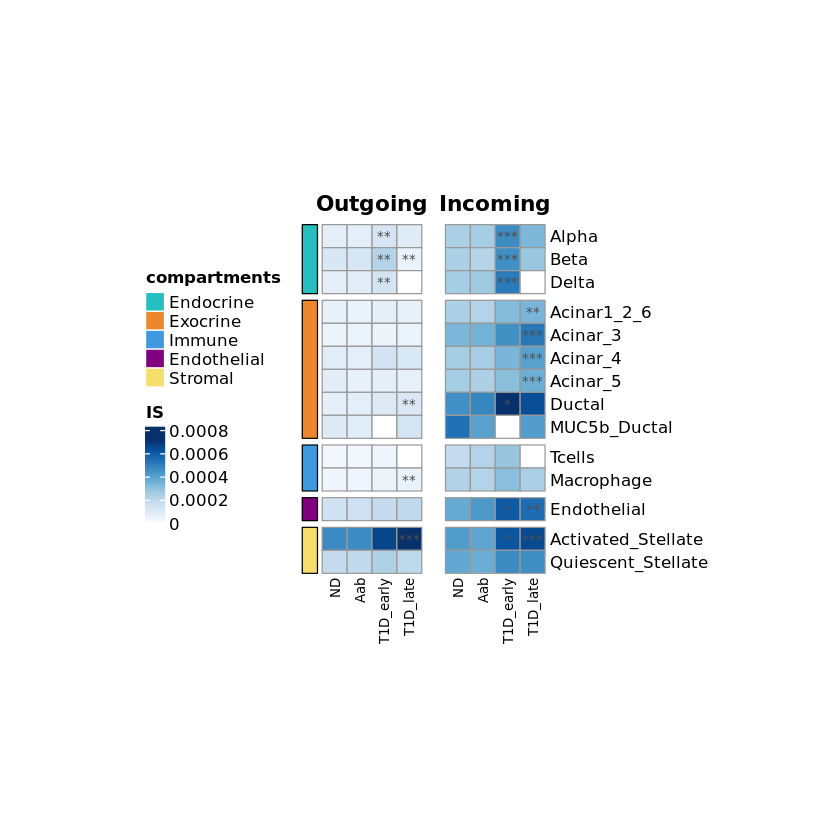

In [16]:
# Plot
# Set color
paletteLength = 1000
col <- c("white",colorRampPalette(brewer.pal(9,"Blues"))(paletteLength-1))

mat = LR.incoming.final
p.incoming = ComplexHeatmap::pheatmap(mat, name = "IS", cluster_cols = F, cluster_rows = F,
              main = "Incoming", na_col = "gray", color = col,
              gaps_row = c(gaps.compartments),
              display_numbers = signaling.roles.incoming.stars,
              cellwidth = 15, cellheight = 15, fontsize_col = 8)


mat = LR.outgoing.final
p.outgoing = ComplexHeatmap::pheatmap(mat, name = "IS", cluster_cols = F, cluster_rows = F,
              main = "Outgoing", na_col = "gray", color = col,
              left_annotation = left_ha,
              gaps_row = c(gaps.compartments),
              display_numbers = signaling.roles.outgoing.stars,
              cellwidth = 15, cellheight = 15, fontsize_col = 8)

ht_list = p.outgoing + p.incoming
draw(ht_list, ht_gap = unit(0.5, "cm"), main_heatmap = 2,
     auto_adjust = TRUE,
     heatmap_legend_side = "left")

Warning message:
“The input is a data frame, convert it to the matrix.”
Warning message:
“The input is a data frame, convert it to the matrix.”
Warning message:
“Heatmap/annotation names are duplicated: Z-scored IS”


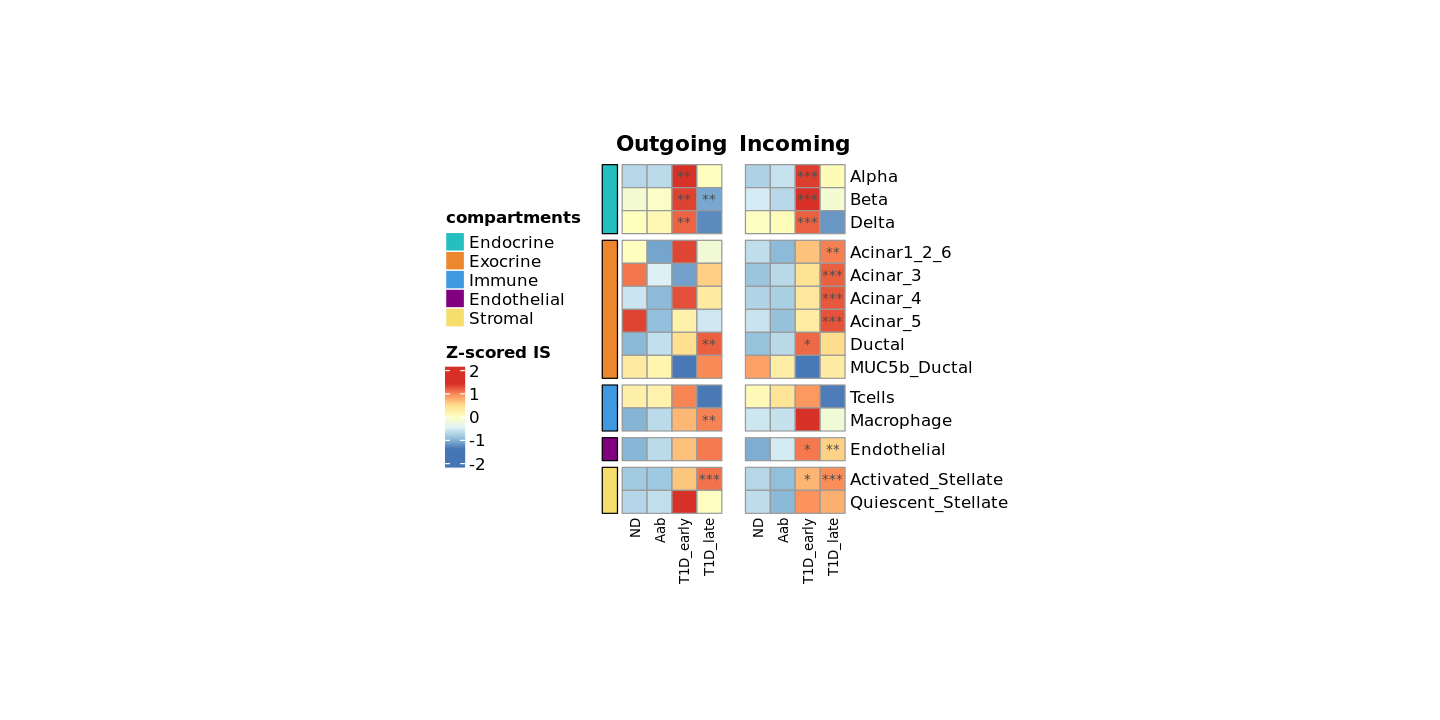

In [17]:
options(repr.plot.width=12, repr.plot.height=6)
# Plot
mat = LR.incoming.final
p.incoming = ComplexHeatmap::pheatmap(mat, name = "Z-scored IS", cluster_cols = F, cluster_rows = F,
              main = "Incoming", na_col = "gray",
              gaps_row = c(gaps.compartments),
              scale = "row",
              display_numbers = signaling.roles.incoming.stars,
              cellwidth = 15, cellheight = 15, fontsize_col = 8)


mat = LR.outgoing.final
p.outgoing = ComplexHeatmap::pheatmap(mat, name = "Z-scored IS", cluster_cols = F, cluster_rows = F,
              main = "Outgoing", na_col = "gray",
              left_annotation = left_ha,
              gaps_row = c(gaps.compartments),
              scale = "row",
              display_numbers = signaling.roles.outgoing.stars,
              cellwidth = 15, cellheight = 15, fontsize_col = 8)

ht_list = p.outgoing + p.incoming
draw(ht_list, ht_gap = unit(0.5, "cm"), main_heatmap = 2,
     auto_adjust = TRUE,
     heatmap_legend_side = "left")

In [19]:
file = paste(permutations.test.res.dir, "Signaling_Roles.pdf", sep = "")
pdf(file, width = 12, height = 6)

# Generate your plot
draw(ht_list, ht_gap = unit(0.5, "cm"), main_heatmap = 2,
     auto_adjust = TRUE,
     heatmap_legend_side = "left")

# Close the PDF device
dev.off()

png 
  2